# OSEkit end-to-end wind pipeline

This example runs the full OSEkit path on the bundled sample audio:
audio dataset creation, spectrogram generation, auxiliary joining, and surface wind estimation.
The auxiliary wind series is synthetic and only exists so the notebook stays self-contained.

In [1]:
import os
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hamming

from osekit.core.audio_dataset import AudioDataset
from osekit.core.auxiliary_dataset import AuxiliaryDataset
from osekit.core.spectro_dataset import SpectroDataset
from osekit.public import SurfaceWindEstimator, extract_surface_wind_feature

%load_ext autoreload
%autoreload 2

In [2]:
os.environ['DISABLE_TQDM'] = 'True'
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

def locate_sample_audio_folder() -> Path:
    candidates = [
        Path.cwd() / '_static' / 'sample_audio' / 'timestamped',
        Path.cwd() / 'docs' / 'source' / '_static' / 'sample_audio' / 'timestamped',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    msg = 'Could not find the bundled sample audio folder.'
    raise FileNotFoundError(msg)

audio_folder = locate_sample_audio_folder()
demo_dir = Path(tempfile.mkdtemp(prefix='osekit_wind_demo_'))
audio_folder, demo_dir

(WindowsPath('C:/Users/m1_gui01/Desktop/OSEkit/docs/source/_static/sample_audio/timestamped'),
 WindowsPath('C:/Users/m1_gui01/AppData/Local/Temp/osekit_wind_demo_8yo9jzs_'))

## 1. Create the audio dataset

Use the timestamped sample WAV files shipped with the repository.

In [3]:
audio_dataset = AudioDataset.from_folder(
    Path('C:/Users/m1_gui01/Desktop/osekit_example/audio/'),
    strptime_format='%y%m%dT%H%M%S',
    timezone = 'UTC',
    mode='files',
    sample_rate=8_000,
    name='sample_audio_demo',
)

print(f'Audio files: {len(audio_dataset.data)}')
print(f'Audio span : {audio_dataset.begin} -> {audio_dataset.end}')

Audio files: 50
Audio span : 2018-04-01 00:10:31+00:00 -> 2018-04-01 08:50:30.000500+00:00


## 2. Generate spectrograms

Build a spectrogram dataset from the audio dataset and inspect the first spectrogram.

Spectrograms: 50


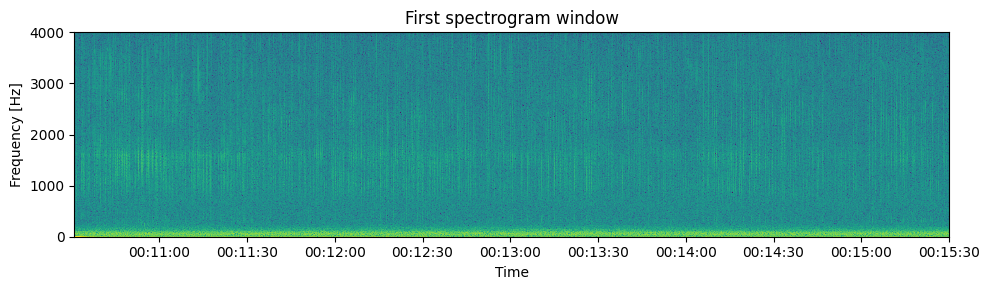

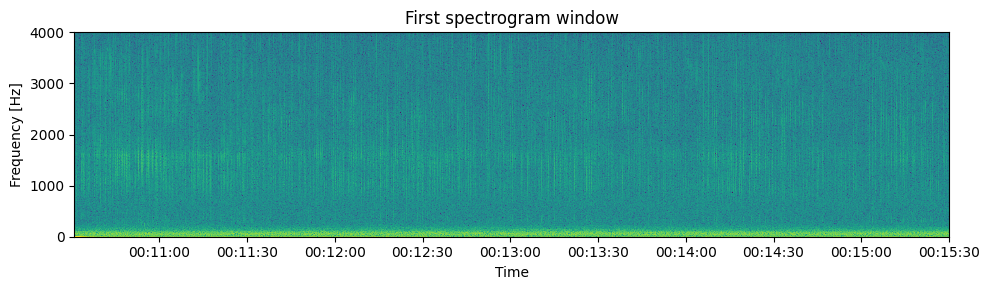

In [4]:
sft = ShortTimeFFT(win=hamming(1024), hop=512, fs=8_000)
spectro_dataset = SpectroDataset.from_audio_dataset(
    audio_dataset,
    fft=sft,
    name='sample_spectro_demo',
)

print(f'Spectrograms: {len(spectro_dataset.data)}')

fig, ax = plt.subplots(figsize=(10, 3))
spectro_dataset.data[0].plot(ax=ax)
ax.set_title('First spectrogram window')
ax.set_xlabel('Time')
ax.set_ylabel('Frequency [Hz]')
fig.tight_layout()
fig

## 3. Create auxiliary wind data

The notebook uses the 8 kHz acoustic feature from the spectrograms to synthesize a matching
`wind_speed_insitu` series. This keeps the example deterministic while still exercising the full auxiliary pipeline.

In [9]:
# aux_output_dir = demo_dir / 'aligned_auxiliary'
# gps_coordinates = (48.0, -4.0)

auxiliary_dataset = AuxiliaryDataset.from_audio_dataset(
    audio_dataset,
    files=['C:/Users/m1_gui01/Desktop/osekit_example/auxiliary/auxiliary/environment/insitu_wind_speed.csv'],
    value_columns=['wind_speed_insitu'])
    # gps_coordinates=gps_coordinates,
    # folder=aux_output_dir,
# )

aligned_auxiliary_frame = pd.concat([data.to_frame() for data in auxiliary_dataset.data],
                                    ignore_index=True)

auxiliary_dataset.write(Path('C:/Users/m1_gui01/Desktop/osekit_example/'))

## 4. Estimate surface wind speed

Fit the wind model on the aligned auxiliary wind speed and the spectrogram feature.

In [21]:
estimator = SurfaceWindEstimator(
    method='Pensieri',
    frequency=8_000,
    wind_speed_column='wind_speed_insitu',
    feature_offset=None,
    scaling_factor=1
)
predicted_frame, prediction_csv = estimator.export(
    spectro_dataset,
    auxiliary_dataset,
    folder=demo_dir / 'surface_wind',
)

print(f'Predicted CSV: {prediction_csv}')
display(pd.DataFrame([estimator.stats_]))
display(predicted_frame.head())

Predicted CSV: C:\Users\m1_gui01\AppData\Local\Temp\osekit_wind_demo_8yo9jzs_\surface_wind\surface_wind_speed.csv


,n_samples,mae,rmse,r2
0,35,0.493377,0.596178,0.627628


,window_begin,window_end,acoustic_level,wind_speed_estimated,timestamp,aggregation,n_rows,n_files,source_files,wind_speed_insitu,wind_model,acoustic_frequency_hz,feature_aggregation,feature_offset,wind_speed_insitu_residual
0,2018-04-01 00:10:31+00:00,2018-04-01 00:15:30.000250+00:00,-70.712729,2.740206,2018-04-01 00:10:31+00:00,mean,1,1,2018_04_01_00_10_31_000000+0000.csv,NaN,Pensieri,8000.0,median,-72.144241,NaN
1,2018-04-01 00:15:31+00:00,2018-04-01 00:26:30.000625+00:00,-72.144241,2.884225,2018-04-01 00:15:31+00:00,mean,1,1,2018_04_01_00_15_31_000000+0000.csv,1.8,Pensieri,8000.0,median,-72.144241,-1.084225
2,2018-04-01 00:31:31+00:00,2018-04-01 00:36:30.000375+00:00,-70.034850,2.711207,2018-04-01 00:31:31+00:00,mean,1,1,2018_04_01_00_31_31_000000+0000.csv,NaN,Pensieri,8000.0,median,-72.144241,NaN
3,2018-04-01 00:36:31+00:00,2018-04-01 00:47:30.000750+00:00,-70.126700,2.713661,2018-04-01 00:36:31+00:00,mean,1,1,2018_04_01_00_36_31_000000+0000.csv,2.0,Pensieri,8000.0,median,-72.144241,-0.713661
4,2018-04-01 00:52:31+00:00,2018-04-01 00:57:30.000375+00:00,-71.419140,2.797233,2018-04-01 00:52:31+00:00,mean,1,1,2018_04_01_00_52_31_000000+0000.csv,NaN,Pensieri,8000.0,median,-72.144241,NaN


## 5. Plot the result

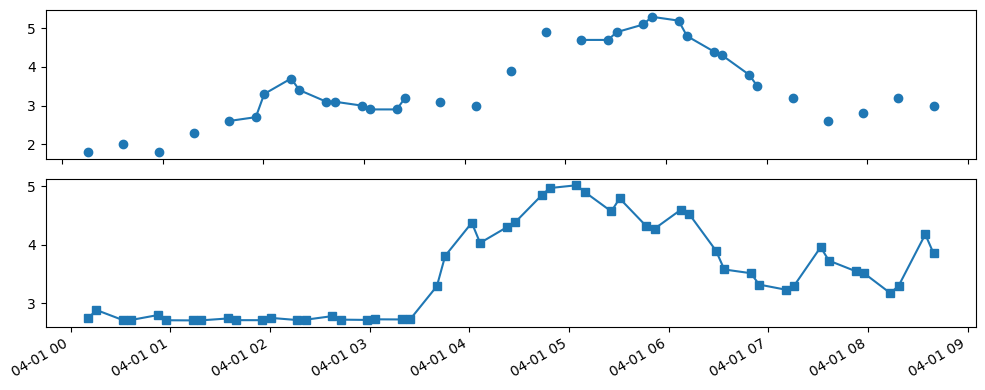

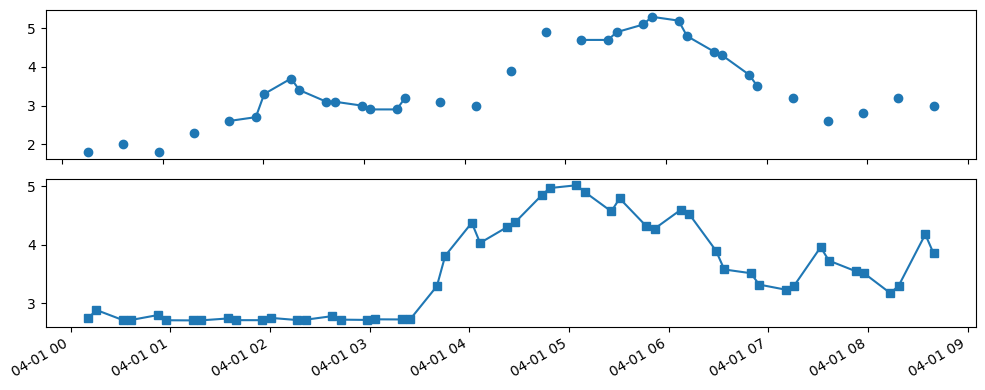

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4))
ax[0].plot(
    predicted_frame['timestamp'],
    predicted_frame['wind_speed_insitu'],
    marker='o',
    label='Auxiliary wind speed',
)
ax[1].plot(
    predicted_frame['timestamp'],
    predicted_frame['wind_speed_estimated'],
    marker='s',
    label='Estimated wind speed',
)
# ax.set_xlabel('Timestamp')
# ax.set_ylabel('Wind speed')
# ax.legend()
# ax.grid(True, alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()
fig

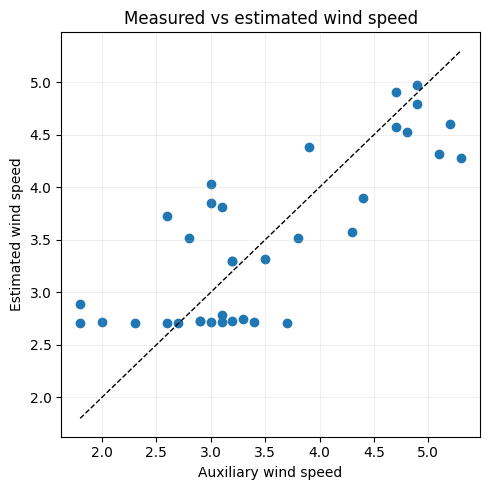

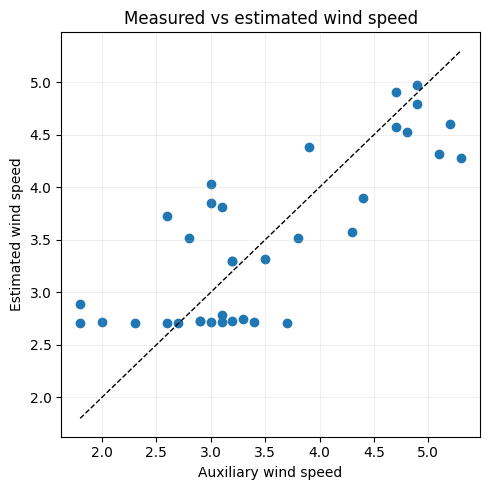

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    predicted_frame['wind_speed_insitu'],
    predicted_frame['wind_speed_estimated'],
    color='tab:blue',
)
min_value = float(
    min(
        predicted_frame['wind_speed_insitu'].min(),
        predicted_frame['wind_speed_estimated'].min(),
    )
)
max_value = float(
    max(
        predicted_frame['wind_speed_insitu'].max(),
        predicted_frame['wind_speed_estimated'].max(),
    )
)
ax.plot([min_value, max_value], [min_value, max_value], color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Auxiliary wind speed')
ax.set_ylabel('Estimated wind speed')
ax.set_title('Measured vs estimated wind speed')
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig

In [ ]:
acoustic_levels = np.asarray(
    [
        extract_surface_wind_feature(
            spectro_data,
            frequency=8_000,
            aggregation='median',
        )
        for spectro_data in spectro_dataset.data
    ],
    dtype=float,
)

raw_auxiliary_frame = pd.DataFrame(
    {
        'timestamp': [audio_data.begin for audio_data in audio_dataset.data],
        'wind_speed_insitu': 0.044642 * acoustic_levels**2 - 3.2917 * acoustic_levels + 63.016,
    }
)

raw_aux_csv = demo_dir / 'raw_auxiliary_wind.csv'
raw_auxiliary_frame.to_csv(raw_aux_csv, index=False)
print(f'Raw auxiliary CSV: {raw_aux_csv}')
raw_auxiliary_frame.head()